# Notebook 07: Aggregate features

Binning a driver feature and attaching per-bin summary statistics gives each row context about the group it belongs to, for example the mean income of all rows in the same latitude band. Bins are quantile-based so every bin holds the same number of rows, and only feature columns are aggregated, so the candidates carry no target information.

We first sweep the bin count with cross-validation to check sensitivity, then screen individual bin-aggregate candidates with the residual scan and BH FDR correction.

## 1. Notebook set-up

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

sys.path.insert(0, str(Path.cwd().resolve().parent / 'src'))
import featurely as fl

from config import (
    AGG_BIN_FEATURES,
    AGG_N_BINS,
    AGG_STATS,
    DATA_DIR,
    PIPELINE_COLORS,
    PIPELINE_RESULTS_PATH,
 )

## 2. Data loading

In [2]:
in_path = DATA_DIR / '06-location-feature-encoding.csv'

if not in_path.exists():
    raise FileNotFoundError(
        (f'Missing required input file: {in_path}. Run 06-location-feature-encoding.ipynb ' +
         'first to generate data/06-location-feature-encoding.csv.')
    )

housing_df = pd.read_csv(in_path)

# Aggregates are computed over the original base features, not the derived
# columns added by earlier notebooks, to keep candidates interpretable.
base_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
print(f'Loaded: {in_path}')

Loaded: /workspaces/featurely/data/06-location-feature-encoding.csv


## 3. Bin count sweep

Too few bins blur regional differences; too many bins make each bin statistic noisy and push the features toward memorizing individual rows. We sweep the bin count for latitude bin means and compare against the baseline with paired t-tests and Holm-Bonferroni correction.

In [3]:
x_base = housing_df.drop('MedHouseVal', axis=1)
y = housing_df['MedHouseVal']

bin_grid = [5, 10, 20, 40]
cv_bin_results = {}

baseline_scores = cross_val_score(LinearRegression(), x_base, y, cv=10, scoring='r2')
cv_bin_results['baseline'] = baseline_scores
print(f'{"baseline":>12}: mean R² = {baseline_scores.mean():.4f} ± {baseline_scores.std():.4f}')

for n_bins in bin_grid:
    agg = fl.compute_bin_aggregates(
        housing_df, 'Latitude', base_features, n_bins=n_bins, stats=AGG_STATS
    )
    scores = cross_val_score(
        LinearRegression(), pd.concat([x_base, agg], axis=1), y, cv=10, scoring='r2'
    )
    cv_bin_results[f'{n_bins} bins'] = scores
    print(f'{f"{n_bins} bins":>12}: mean R² = {scores.mean():.4f} ± {scores.std():.4f}')

    baseline: mean R² = 0.6201 ± 0.0786


      5 bins: mean R² = 0.6310 ± 0.0676


     10 bins: mean R² = 0.6113 ± 0.0973


     20 bins: mean R² = 0.5999 ± 0.0992


     40 bins: mean R² = 0.6112 ± 0.0933


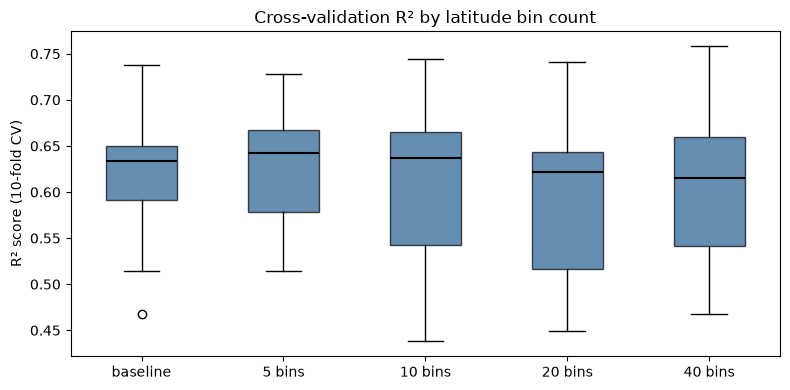


Paired t-tests vs baseline (Holm-Bonferroni; * = p_corr < 0.05):
  baseline vs     5 bins: t = -1.5120,  p_raw = 0.1648,  p_corr = 0.4945
  baseline vs    10 bins: t = +1.0334,  p_raw = 0.3284,  p_corr = 0.6567
  baseline vs    20 bins: t = +1.9461,  p_raw = 0.0835,  p_corr = 0.3339
  baseline vs    40 bins: t = +0.7687,  p_raw = 0.4618,  p_corr = 0.6567


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))

bp = ax.boxplot(
    cv_bin_results.values(),
    tick_labels=list(cv_bin_results.keys()),
    patch_artist=True
)

for patch in bp['boxes']:
    patch.set_facecolor(PIPELINE_COLORS.get('+ aggregates', '#255e91'))
    patch.set_alpha(0.7)

for median in bp['medians']:
    median.set(color='black', linewidth=1.5)

ax.set_title('Cross-validation R² by latitude bin count')
ax.set_ylabel('R² score (10-fold CV)')
plt.tight_layout()
plt.show()

paired_keys = [k for k in cv_bin_results if k != 'baseline']
t_stats, p_raws = [], []

for k in paired_keys:
    t_stat, p_raw = ttest_rel(baseline_scores, cv_bin_results[k])
    t_stats.append(t_stat)
    p_raws.append(p_raw)

reject, p_corrected, _, _ = multipletests(p_raws, alpha=0.05, method='holm')

print('\nPaired t-tests vs baseline (Holm-Bonferroni; * = p_corr < 0.05):')

for k, t_stat, p_raw, p_corr, rej in zip(paired_keys, t_stats, p_raws, p_corrected, reject):
    marker = ' *' if rej else ''
    print(f'  baseline vs {k:>10}: t = {t_stat:+.4f},  p_raw = {p_raw:.4f},  p_corr = {p_corr:.4f}{marker}')

## 4. Candidate scan at the selected bin count

With the bin count fixed by the sweep (recorded in `config.py` as `AGG_N_BINS`), we build bin-aggregate candidates for each configured driver feature and screen them individually against baseline residuals. When the driver itself appears in the aggregate list it is excluded, since its bin mean is nearly a copy of itself.

Baseline R2 (in-sample): 0.7149

    Latitudebin10_mean_MedInc: r = +0.0299,  p = 0.0000
  Latitudebin10_mean_HouseAge: r = +0.0516,  p = 0.0000
  Latitudebin10_mean_AveRooms: r = -0.0606,  p = 0.0000
 Latitudebin10_mean_AveBedrms: r = -0.0336,  p = 0.0000
Latitudebin10_mean_Population: r = +0.0431,  p = 0.0000
  Latitudebin10_mean_AveOccup: r = -0.0098,  p = 0.1610
    MedIncbin10_mean_HouseAge: r = -0.0048,  p = 0.4871
    MedIncbin10_mean_AveRooms: r = +0.0141,  p = 0.0431
   MedIncbin10_mean_AveBedrms: r = -0.0030,  p = 0.6708
  MedIncbin10_mean_Population: r = -0.0457,  p = 0.0000
    MedIncbin10_mean_AveOccup: r = +0.0259,  p = 0.0002


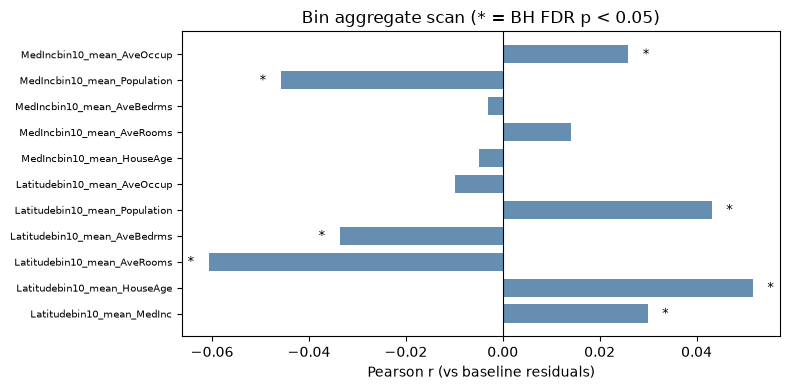

In [5]:
candidate_frames = []

for bin_feature in AGG_BIN_FEATURES:
    agg_cols = [c for c in base_features if c != bin_feature]
    candidate_frames.append(
        fl.compute_bin_aggregates(
            housing_df, bin_feature, agg_cols, n_bins=AGG_N_BINS, stats=AGG_STATS
        )
    )

agg_candidates = pd.concat(candidate_frames, axis=1)

scan_results = fl.run_candidate_scan(housing_df, agg_candidates)

sig_dict = fl.plot_candidate_scan(
    scan_results,
    title='Bin aggregate scan (* = BH FDR p < 0.05)',
    color=PIPELINE_COLORS.get('+ aggregates', '#255e91'),
 )

## 5. Add selected aggregate features

In [6]:
sig_cols = [c for c, s in sig_dict.items() if s]

if sig_cols:
    housing_df = pd.concat([housing_df, agg_candidates[sig_cols]], axis=1)
    print(f'Added {len(sig_cols)} aggregate feature(s).')

else:
    print('No aggregate features passed significance threshold.')

Added 7 aggregate feature(s).


## 6. Performance evaluation

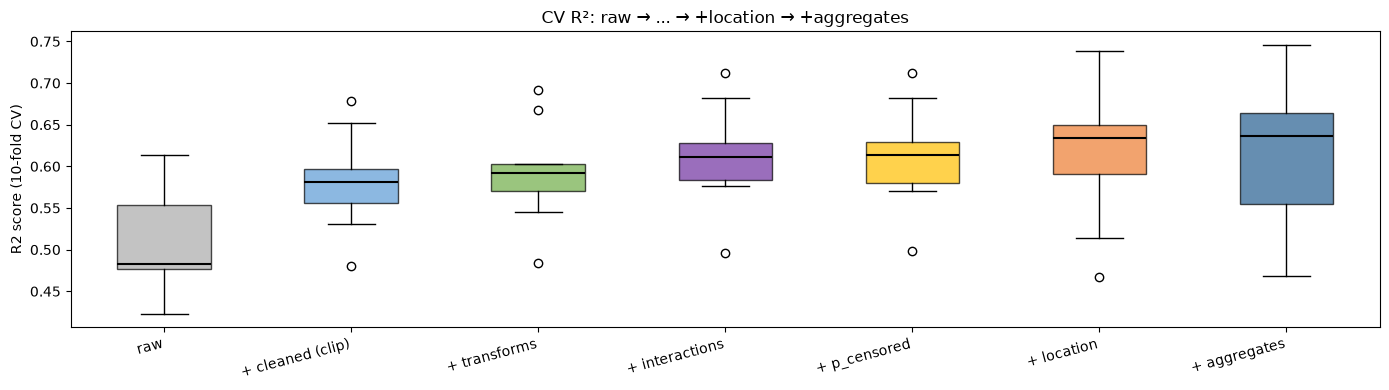

                      raw: mean R2 = 0.5110 ± 0.0593  (+0.00% vs raw)
         + cleaned (clip): mean R2 = 0.5811 ± 0.0536  (+13.71% vs raw)
             + transforms: mean R2 = 0.5923 ± 0.0551  (+15.90% vs raw)
           + interactions: mean R2 = 0.6122 ± 0.0561  (+19.81% vs raw)
             + p_censored: mean R2 = 0.6120 ± 0.0564  (+19.76% vs raw)
               + location: mean R2 = 0.6201 ± 0.0786  (+21.34% vs raw)
             + aggregates: mean R2 = 0.6199 ± 0.0851  (+21.31% vs raw)


In [7]:
results_df = fl.add_pipeline_step(
    None,
    '+ aggregates',
    housing_df.drop('MedHouseVal', axis=1),
    housing_df['MedHouseVal'],
    color=PIPELINE_COLORS.get('+ aggregates', '#255e91'),
    results_path=PIPELINE_RESULTS_PATH,
 )

fl.plot_pipeline_steps(
    results_df,
    title='CV R²: raw → ... → +location → +aggregates',
    results_path=PIPELINE_RESULTS_PATH,
 )

## 7. Save output

In [8]:
out_path = DATA_DIR / '07-aggregate-features.csv'
housing_df.to_csv(out_path, index=False)
print(f'Saved: {out_path}')

Saved: /workspaces/featurely/data/07-aggregate-features.csv
